# 0. Project context and library imports

## Project objective and methodology

This project implements a variational quantum classifier inspired by Havlíček et al., *[Supervised learning with quantum enhanced feature spaces](https://arxiv.org/pdf/1804.11326)*. Its main objective is to study how the depth of the variational circuit affects classification performance and to evaluate the method later on real quantum hardware.

The dataset is generated artificially from two-dimensional points in the domain $(0, 2\pi]^2$. Each point is encoded into a two-qubit quantum state using the feature map proposed in the paper. Labels $+1$ and $-1$ are assigned from the expectation value of a parity observable transformed by a random unitary. Points close to the decision boundary are discarded using a gap of $\Delta=0.3$, producing a balanced and clearly separated dataset.

The classifier consists of the quantum feature map followed by a variational ansatz that alternates parameterized single-qubit rotations and entangling CZ gates. The circuit parameters and the classification bias are optimized with SPSA, while the parity of the measured bit strings determines the predicted class.

We will compare circuits with one to four variational layers to analyze the effect of circuit depth on the loss and classification accuracy. Finally, the best parameters obtained in simulation for the one-layer model will be used to initialize an execution on real quantum hardware. We will then perform fine-tuning directly on the device to determine whether adapting the model to its noise and hardware characteristics can improve the results.

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_algorithms.utils import algorithm_globals
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import(
    Operator,
    SparsePauliOp,
    Statevector,
    random_unitary
)
from qiskit_ibm_runtime import(
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
    QiskitRuntimeService
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import SPSA
from scipy.special import expit
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

SEED = 1234  # For reproducibility
np.random.seed( SEED)
random.seed(SEED)
algorithm_globals.random_seed = SEED

# 1. Feature map

We want to implement the Unitary: 
$$\mathcal{U}_{\Phi}(\vec{x}) = U_{\Phi(\vec{x})} H^{\otimes n} U_{\Phi(\vec{x})} H^{\otimes n}$$
where $H$ is the conventional Hadamard gate and:
$$U_{\phi(\vec{x})}=\exp \left(i\sum_{S\subseteq[n]}\phi_S(\vec{x})\prod_{i \in S}Z_i\right)$$
Since we are using $n=d=2$ qbits, we have:
$$\phi_{\{i\}}(\vec{x})=x_i$$
$$\phi_{\{1,2\}}=(\pi-x_1)(\pi-x_2)

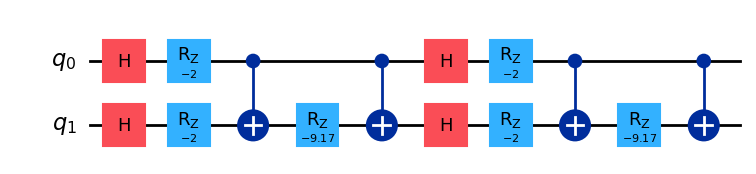

In [2]:
def create_feature_map(x: np.ndarray) -> QuantumCircuit:
    """
    Creates a 2 qbit feature map circuit for the given input.
    """
    fm = QuantumCircuit(2)
    for _ in range(2):
        # Hadamards layer
        fm.h([0,1])

        # Individual phases
        fm.rz(-2*x[0], 0)
        fm.rz(-2*x[1], 1)

        # Interactions
        phi_12 = (np.pi-x[0])*(np.pi-x[1])
        fm.cx(0,1) # Parity
        fm.rz(-2*phi_12, 1) # Apply interaction phase
        fm.cx(0,1) # Uncompute parity

    return fm

# Example for visualization
fm = create_feature_map(np.array([1, 1]))
fm.draw('mpl')

# 2. Artificial data

We construct a training set $T$ and a test set $S$ of a subset $\Omega \subset \mathbb{R}^d$, both labeled by a map $m: T \cup S \rightarrow \{+1, -1\}$. We define the parity function as $f = Z_1 Z_2$ and select a random unitary $V \in SU(4)$:

- The data vectors are random points $\vec{x} \in T \cup S \subset (0, 2\pi]^2$
- We assign $m(\vec{x}) = +1$ when the expectation value $\langle \Phi(\vec{x}) | V^{\dagger} f V | \Phi(\vec{x}) \rangle \geq \Delta$
- We assign $m(\vec{x}) = -1$ when $\langle \Phi(\vec{x}) | V^{\dagger} f V | \Phi(\vec{x}) \rangle \leq -\Delta$

This labeling is performed for a chosen value of $\Delta$, which defines the separation gap between the two classes.

In [3]:
def random_su(
        n: int,
        seed: int = SEED
    ) -> np.ndarray:
    """
    Generates a random SU(n) matrix.
    """
    V_operator = random_unitary(n, seed=seed)
    V_matrix = V_operator.data
    V_su = V_matrix / (np.linalg.det(V_matrix)**(1/n))
    
    return V_su

def build_decision_map(
        resolution: int,
        gap: float,
        n_samples: int,
        seed: int = SEED
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """"
    Builds a decision map for the given resolution and gap.
    """
    if n_samples % 2 != 0:
        raise ValueError("n_samples must be even to generate balanced classes.")

    # Rng with seed for reproducibility
    rng = np.random.default_rng(seed)

    # Generate a random SU(4) matrix for the observable
    V_su4 = random_su(4, seed=seed)
    f = np.diag([1, -1, -1, 1])
    observable = V_su4.conj().T @ f @ V_su4
    observable_op = Operator(observable)

    # The complete decision map (for visualization)
    x_data = np.linspace(0, 2 * np.pi, resolution + 1)[1:]
    x_grid, y_grid = np.meshgrid(x_data, x_data)
    z_values = np.zeros((resolution, resolution))

    for i in range(resolution):
        for j in range(resolution):
            point = [x_grid[i, j], y_grid[i, j]]
            state = Statevector.from_instruction(create_feature_map(point))
            val = np.real(state.expectation_value(observable_op))

            if val >= gap:
                z_values[i, j] = 1
            elif val <= -gap:
                z_values[i, j] = -1

    # Random balanced points for train/test
    final_x = []
    labels = []

    target_per_class = n_samples // 2
    class_counts = {1: 0, -1: 0}

    while class_counts[1] < target_per_class or class_counts[-1] < target_per_class:
        point = rng.uniform(0, 2 * np.pi, size=2)
        state = Statevector.from_instruction(create_feature_map(point))
        val = np.real(state.expectation_value(observable_op))

        if val >= gap and class_counts[1] < target_per_class:
            final_x.append(point)
            labels.append(1)
            class_counts[1] += 1

        elif val <= -gap and class_counts[-1] < target_per_class:
            final_x.append(point)
            labels.append(-1)
            class_counts[-1] += 1


    return np.array(final_x), np.array(labels), np.array(z_values)

def plot_decision_map(
        z_values: np.ndarray,
        X_train: np.ndarray,
        X_test: np.ndarray,
        misclassified_points: list[np.ndarray] = None
    ) -> None:
    """
    Plots the decision map using the z-values and misclassified points (if provided).
    """
    plt.figure(figsize=(7,7))
    
    xmax = 2 * np.pi
    
    plt.imshow(
        z_values,
        extent=[0, xmax, 0, xmax],
        origin='lower',
        cmap='RdBu'
    )
    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c='green',
        marker='x',
        s=25, 
        label='Training Data'
    )
    plt.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c='orange',
        marker='x',
        s=25,
        label='Test Data'
    )

    ncol = 2

    if misclassified_points:
        misclassified_points = np.array(misclassified_points)
        plt.scatter(
            misclassified_points[:, 0],
            misclassified_points[:, 1],
            edgecolors='red', 
            facecolors='none',
            marker='o',
            s=80,
            label='Misclassified Points'
        )
        ncol = 3

    plt.legend(
        bbox_to_anchor=(0.5, -0.07),
        loc='upper center',
        ncol=ncol
    )
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title("Complete Quantum Feature Map")
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

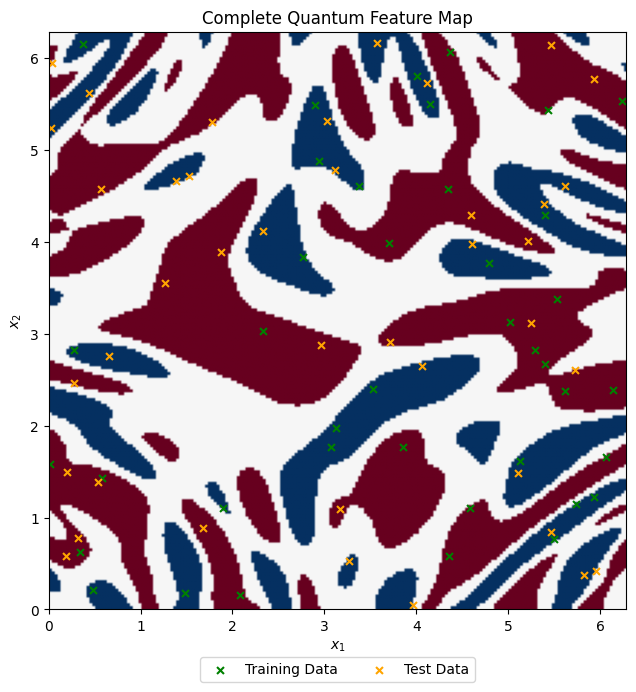

In [4]:
n_samples = 80

final_x, labels, z_values = build_decision_map(
    resolution=200,
    gap=0.3,
    n_samples=n_samples,
    seed=SEED
)

n_train = 40 
n_test = n_samples - n_train 

X_train, X_test, y_train, y_test = train_test_split(
    final_x, 
    labels, 
    train_size=n_train, 
    test_size=n_test,
    stratify=labels,     
    random_state=SEED,   
    shuffle=True       
)

plot_decision_map(
    z_values,
    X_train,
    X_test,
    misclassified_points=None
    )

# 3. Quantum Variational Classification

For this classification technique, we will follow four steps:

- **First**, we map our data $x\in \Omega$ to a quantum state by applying the feature map $\mathcal{U}_{\phi(\vec{x})}$ to a reference state $|0\rangle^{\otimes{n}}$.
- **Second**, we apply a $l$ layer circuit $W(\vec{\theta})$ to the feature state. The chosen ansantz is:
  $$W(\vec{\theta}) = U_{loc}^{(l)} (\theta_l) U_{ent} ... U_{loc}^{(2)} (\theta_2) U_{ent} U_{loc}^{(1)} (\theta_1) U_{ent}$$
  alternating entangling gates:
  $$U_{ent} = \prod_{(i,j)\in E} CZ(i,j)$$
  where $(i,j)\in E $ are the edges present in the conectivity of the superconducting chip, with full layers single qubit rotations:

  $$U_{loc}^{(t)}(\theta_t) = \otimes_{i=1}^n U(\theta_{i,t})$$
  where $U(\theta_{i,t})\in SU(2)$.

- **Third**, the measurement operator $M_y=2^{-1}(\mathbb{I}+yf)$ where $f=\sum_{z\in\{0,1\}} f(z)|z\rangle \langle z|$ is applied to the state $W(\vec\theta)\mathcal{U}_{\phi(\vec{x})}|0\rangle^{\otimes{n}}$. The probability of obtaining outcome $y$ is $p_y=\langle \Phi(\vec{x}) | W^{\dagger}(\vec{\theta}) M_y W(\vec{\theta}) | \Phi(\vec{x}) \rangle$
- **Fourth**, for the decision rule, we perform $R$ repeated measurement shots to obtain the empirical distribution $\hat{p}_y(\vec{x})$. We assign the label $\tilde{m}(\vec{x}) = y$ whenever:
  $$\hat{p}_y(\vec{x}) > \hat{p}_{-y}(\vec{x}) - yb$$
  where we have introduced an additional bias parameter $b \in [-1, 1]$ that can be optimized during training.

The goal of the training process is to minimize the empirical risk, which represents the average probability of misclassification over the training set $T$:

$$R_{emp}(\vec{\theta}) = \frac{1}{|T|} \sum_{\vec{x} \in T} \Pr(\tilde{m}(\vec{x}) \neq m(\vec{x}))$$

where $|T|$ is the number of samples in the training set, $\tilde{m}(\vec{x})$ is the label assigned by the quantum classifier, and $m(\vec{x})$ is the true label. Since we are working with shots, this probabily arises from the times that the measurement gives the incorrect label and its given by the binomial cumulative density function (CDF) of the empirical distribution $\hat{p}_y (\vec{x})$. For $R \gg 1$, this probabily can be approximated by:
$$\Pr(\tilde{m}(\vec{x}) \neq m(\vec{x})) \approx \text{sig} \left( \frac{\sqrt{R} \left( \frac{1}{2} - \left( \hat{p}_y(\vec{x}) - \frac{yb}{2} \right) \right)}{\sqrt{2(1 - \hat{p}_y(\vec{x})) \hat{p}_y(\vec{x})}} \right)$$

# **IMPLEMENTATION**

First we define the ansantz $W(\theta)$ and the full circuit $W(\theta)U_{\phi}(x)|0\rangle$

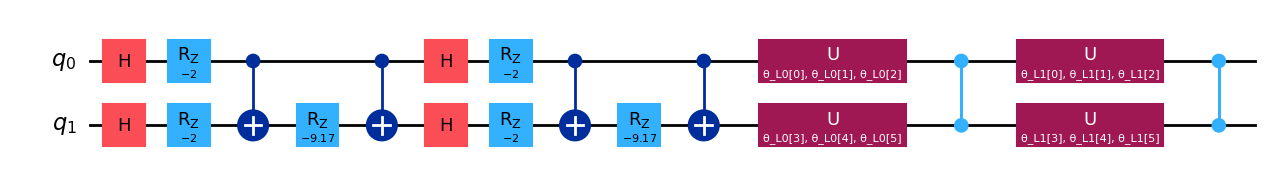

In [5]:
def entangling_gates(
        conectivity_list: list[list[int]],
        n_qubits: int = 2
    ) -> QuantumCircuit:
    """
    Builds the entangling gates based on the conectivity of the chip.
    """
    qc = QuantumCircuit(n_qubits)
    for control, target in conectivity_list:
        qc.cz(control, target)

    return qc

def rotation_gates(
        layer_index: int,
        n_qubits: int = 2
    ) -> QuantumCircuit:
    """
    Builds the parameterized rotation gates SU(2) for each qubit.
    """
    qc = QuantumCircuit(n_qubits)
    
    # 3 parameters per qubit for a full SU(2) rotation
    params = ParameterVector(f'θ_L{layer_index}', 3 * n_qubits)
    
    for qbit in range(n_qubits):
        idx = qbit * 3
        qc.u(params[idx], params[idx+1], params[idx+2], qbit)

    return qc


def build_ansatz(
        n_layers: int,
        conectivity_list: list[list[int]] = [[0, 1]],
        n_qubits: int = 2
    ) -> QuantumCircuit:
    """
    Builds the ansatz circuit based on the given parameters, number of layers and conectivity of the chip.
    """
    qc = QuantumCircuit(n_qubits)

    for layer in range(n_layers):
        qc.compose(
            rotation_gates(layer, n_qubits),
            inplace=True
        )
        qc.compose(
            entangling_gates(conectivity_list, n_qubits),
            inplace=True
        )

    return qc

def build_full_circuit_parametrized(
        x: np.ndarray,
        ansatz: QuantumCircuit
    ) -> QuantumCircuit:
    """
    Builds W(theta)U_phi(x)|0> by composing the feature map and the ansatz.
    """
    qc = create_feature_map(x)
    qc.compose(
        ansatz,
        inplace=True
    )

    return qc

# Example for visualization
ansatz = build_ansatz(
    n_layers=2,
    conectivity_list=[[0,1]],
    n_qubits=2
)
full_circuit = build_full_circuit_parametrized(
    x=np.array([1, 1]),
    ansatz=ansatz
)
full_circuit.draw('mpl')

We can get the label probabilies either using counts or the expected value of ZZ.

In [6]:
def counts_to_label_probs(
        counts: dict,
        shots: int
    ) -> dict[int, float]:
    """
    Computes p(+1) and p(-1) from measurement counts.
    """
    even_counts = 0
    odd_counts = 0

    for bitstring, count in counts.items():
        clean_bitstring = bitstring.replace(" ", "")

        if clean_bitstring.count("1") % 2 == 0:
            even_counts += count
        else:
            odd_counts += count

    p_plus = even_counts / shots
    p_minus = odd_counts / shots

    return {
        +1: p_plus,
        -1: p_minus
    }

def expval_to_label_probs(exp_zz: float) -> dict[int, float]:
    """
    Converts the expectation value <ZZ> into p(+1) and p(-1).
    """
    exp_zz = float(np.real(exp_zz))
    exp_zz = np.clip(exp_zz, -1.0, 1.0)

    p_plus = (1 + exp_zz) / 2
    p_minus = (1 - exp_zz) / 2

    return {
        +1: float(p_plus),
        -1: float(p_minus)
    }
    

Now we create a function for the loss, that will be used in the cost function later.

In [7]:
def prob_aprox(
        y: int,
        py: float,
        b: float,
        R: int
    ) -> float:
    """
    Calculates the probability of misclassification approximation.
    """
    # To avoid division by zero.
    epsilon = 1e-10
    
    num = math.sqrt(R) * (0.5 - (py - (y * b / 2)))
    denom = math.sqrt(2 * (1 - py) * py + epsilon)

    return expit(num / denom)

def loss(
        y_true: list[int],
        y_probs: list[float],
        bias: float,
        R: int
    ) -> float:
    """
    Calculates the loss of the model based on the predicted probabilities and true labels.
    """
    sum_probs = 0
    for y, py in zip(y_true, y_probs):
        prob = prob_aprox(y, py, bias, R)
        sum_probs += prob

    return sum_probs / len(y_true) 

If using Estimator, we need a loss function without shots.

In [8]:
def prob_aprox_estimator(
        y: int,
        py: float,
        b: float,
        alpha: float = 10.0
    ) -> float:
    """
    Smooth approximation of the misclassification probability without shots.
    """
    margin = py - (y * b / 2) - 0.5

    return expit(-alpha * margin)


def loss_estimator(
        y_true: list[int],
        y_probs: list[float],
        bias: float,
        alpha: float = 10.0
    ) -> float:
    """
    Loss for exact probabilities obtained with Estimator or Statevector.
    """
    sum_probs = 0

    for y, py in zip(y_true, y_probs):
        prob = prob_aprox_estimator(y, py, bias, alpha)
        sum_probs += prob

    return sum_probs / len(y_true)

Using all of these functions we can build the training loop.

In [9]:
USE_ESTIMATOR = True # If True, uses Estimator. If False, uses shot-based simulation.

if USE_ESTIMATOR:
    estimator = StatevectorEstimator()
else:
    backend = AerSimulator(seed_simulator=SEED)
    sampler = Sampler(mode=backend)


MAX_ITERS = 200
SHOTS = 2000 

conectivity_list = [[0, 1]]  
list_layers = range(1, 5)

results = []
history = []

for n_layers in tqdm(list_layers, desc="Layers"):
    # 1. Build the ansatz
    ansatz = build_ansatz(n_layers, conectivity_list) # W(theta)
    ansatz_params = list(ansatz.parameters)

    # 2. Define the observable (for 2 qubits, it's just ZZ)
    observable = SparsePauliOp.from_list([("ZZ", 1.0)])

    # 3. Build the exact training circuit templates without measurements (this is because we use statevector simulator)
    exact_templates = []

    for x in X_train:
        qc = build_full_circuit_parametrized(x, ansatz)
        exact_templates.append(qc) # No measurements here, we will use statevector simulator for exact probabilities.

    # 4. Build and transpile the shot-based training circuit templates only once per layer (for optimization efficiency)
    shot_templates = []

    if not USE_ESTIMATOR:
        for circuit in exact_templates:
            qc = circuit.copy()
            qc.measure_all() # Add measurements for shot-based simulation
            shot_templates.append(qc)

        transpiled_templates = transpile(
            shot_templates,
            backend,
            seed_transpiler=SEED
        ) # Transpile once for all iterations to save time during optimization.

    # 5. Define the cost function
    def cost_function(params: list[float]) -> float:
        """
        Cost function that takes the parameters, builds the circuit, gets the predicted probabilities and calculates the loss.
        """
        theta = params[:-1]
        bias = np.tanh(float(params[-1])) # Tanh so the bias is between -1 and 1.
        param_bind = dict(zip(ansatz_params, theta))

        # Now we can get the probabilities

        # ############################
        # ESTIMATOR-BASED SIMULATION
        # ############################
        if USE_ESTIMATOR:
            bound_circuits = [
                circuit.assign_parameters(param_bind, inplace=False)
                for circuit in exact_templates
            ]
            pubs = [
                (circuit, observable)
                for circuit in bound_circuits
            ]
            job = estimator.run(pubs)
            results = job.result()
           
            y_probs = []

            for i, y in enumerate(y_train):
                exp_zz = np.asarray(results[i].data.evs).reshape(-1)[0]
                probs = expval_to_label_probs(exp_zz)
                py = probs[int(y)] # Probability of the true label y
                y_probs.append(py)

            return loss_estimator(y_train, y_probs, bias)


        # ############################
        # SHOT-BASED SIMULATION
        # ############################
        else:
            bound_circuits = [
                circuit.assign_parameters(param_bind, inplace=False)
                for circuit in transpiled_templates
            ]
            job = sampler.run(bound_circuits, shots=SHOTS) # Just one call to the backend.
            result = job.result() 
            y_probs = []

            for i, y in enumerate(y_train):
                counts = result[i].data.meas.get_counts()
                probs = counts_to_label_probs(counts, SHOTS)

                py = probs[int(y)] # Probability of the true label y
                y_probs.append(py)
        return loss(y_train, y_probs, bias, SHOTS)
    
    # 6. Assign random parameters for initialization
    num_params = len(ansatz_params) # 3 parameters per qubit per layer
    parameter_rng = np.random.default_rng(SEED)
    initial_theta = parameter_rng.random(num_params) * 2 * np.pi
    initial_bias = np.array([0.0])
    initial_params = np.concatenate([initial_theta, initial_bias])

    # 7. Compute and save initial loss
    initial_loss = cost_function(initial_params)
    loss_history = [initial_loss]
    
    # 8. Initialize tqdm progress bar for the optimization iterations
    pbar = tqdm(
        total=MAX_ITERS,
        desc=f"{n_layers} layers",
        leave=False
    )

    # 9. Define the callback function for SPSA to store the loss history
    def callback(nfev, parameters, loss_value, stepsize, accepted):
        """
        Callback for SPSA. Stores the loss after each optimizer iteration.
        """
        loss_history.append(loss_value)
        pbar.update(1)
        pbar.set_postfix({"loss": f"{loss_value:.4f}", "nfev": nfev})

    # 10. Optimize parameters using SPSA
    spsa = SPSA(
        maxiter=MAX_ITERS,
        callback=callback
    )
    result = spsa.minimize(
        fun=cost_function,
        x0=initial_params
    ) 

    results.append(result)
    history.append(loss_history)
    
    pbar.close()

Layers:   0%|          | 0/4 [00:00<?, ?it/s]

1 layers:   0%|          | 0/200 [00:00<?, ?it/s]

2 layers:   0%|          | 0/200 [00:00<?, ?it/s]

3 layers:   0%|          | 0/200 [00:00<?, ?it/s]

4 layers:   0%|          | 0/200 [00:00<?, ?it/s]

# 4. Plot loss curves and validate final models

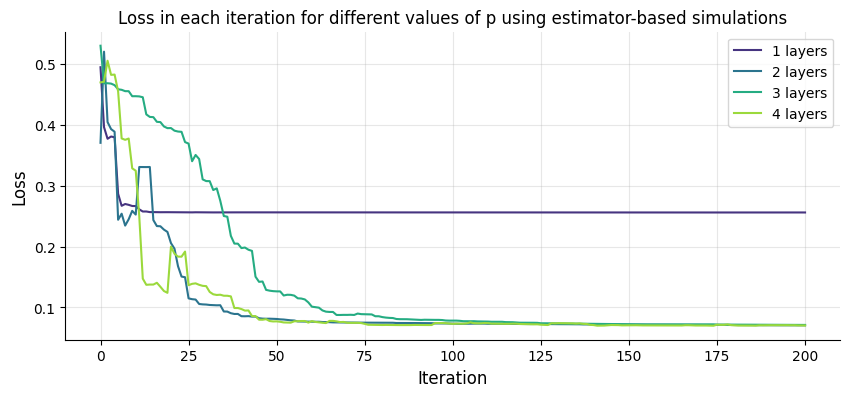

In [10]:
plt.figure(figsize=(10, 4))

norm_values = np.linspace(0.15, 0.85, len(list_layers))
colors = plt.cm.viridis(norm_values)

for color, n_layers, loss_history in zip(colors, list_layers, history):
    plt.plot(
        range(len(loss_history)),
        loss_history,
        label=f"{n_layers} layers",
        linewidth=1.5,
        color=color
    )
ax = plt.gca()
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
if USE_ESTIMATOR:
    plt.title(f"Loss in each iteration for different values of p using estimator-based simulations")
else:
    plt.title(f"Loss in each iteration for different values of p using shot-based simulations")
plt.show()

Now we validate the model with the test dataset.

In [11]:
def test_model(
        params: list[float],
        ansatz: QuantumCircuit,
        observable: SparsePauliOp
    ) -> tuple[float, list[np.ndarray]]:
    """
    Tests the model on the test set using the optimized parameters and returns the accuracy and misclassified points.
    """
    theta = params[:-1]
    ansatz_params = list(ansatz.parameters)
    param_bind = dict(zip(ansatz_params, theta))

    correct = 0
    missclassified_points = []

    if USE_ESTIMATOR:
        bound_circuits = []

        circuits = [
            build_full_circuit_parametrized(x, ansatz)
            for x in X_test
        ]
        bound_circuits = [
            circuit.assign_parameters(param_bind, inplace=False)
            for circuit in circuits
        ]
        pubs = [
            (circuit, observable)
            for circuit in bound_circuits
        ]
        job = estimator.run(pubs)
        results = job.result()
        
        for i, (x, y) in enumerate(zip(X_test, y_test)):
            exp_zz = np.asarray(results[i].data.evs).reshape(-1)[0]
            probs = expval_to_label_probs(exp_zz)

            predicted_label = +1 if probs[+1] > probs[-1] else -1

            if predicted_label == y:
                correct += 1
            else:
                missclassified_points.append(x)

    else:
        test_circuits = []

        for x in X_test:
            qc = build_full_circuit_parametrized(x, ansatz)
            qc.measure_all()
            test_circuits.append(qc)

        transpiled_circuits = transpile(
            test_circuits,
            backend
        )
        bound_circuits = [
            circuit.assign_parameters(param_bind, inplace=False)
            for circuit in transpiled_circuits
        ]
        result = backend.run(
            bound_circuits,
            shots=SHOTS
        ).result()

        for i, y in enumerate(y_test):
            counts = result.get_counts(i)
            probs = counts_to_label_probs(counts, SHOTS)

            py_plus = probs[+1]
            py_minus = probs[-1]

            predicted_label = +1 if py_plus > py_minus else -1

            if predicted_label == y:
                correct += 1
            else:
                missclassified_points.append(X_test[i])

    accuracy = correct / len(X_test)

    return accuracy, missclassified_points

In [12]:
accuracy_list = []
missclassified_points_list = []

for n_layers, result in zip(list_layers, results):
    ansatz = build_ansatz(
        n_layers,
        conectivity_list
    )
    accuracy, misclassified_points = test_model(
        result.x,
        ansatz,
        observable
    )
    accuracy_list.append(accuracy)
    missclassified_points_list.append(misclassified_points)
    
    print(f"Accuracy for {n_layers} layers: {accuracy:.2f}")

Accuracy for 1 layers: 0.72
Accuracy for 2 layers: 1.00
Accuracy for 3 layers: 1.00
Accuracy for 4 layers: 1.00


From 2 layers onward, we archieve 100% accuracy. We can visualize the missclasified points for 1 layer.

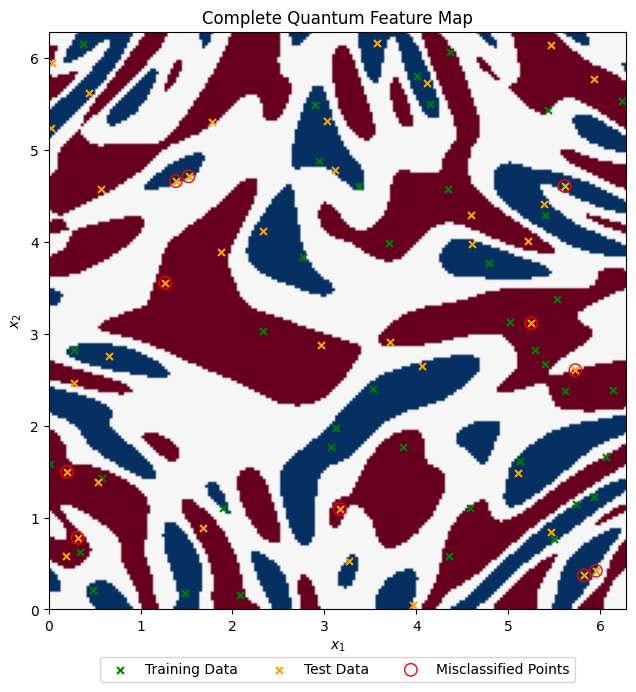

In [13]:
plot_decision_map(
    z_values,
    X_train,
    X_test,
    missclassified_points_list[0]
) 

# 5. Real hardware run

Now we can run the model on real quantum hardware and use fine-tuning to try to improve the results obtained with one layer. However, I have no remaining execution time available on IBM Cloud, so the following cells are left unexecuted.


In [19]:
service = QiskitRuntimeService()

QiskitRuntimeService.save_account(
    token="API_KEY",
    set_as_default = True,
    overwrite=True
)

backend_ibm = service.least_busy(
    operational=True,
    simulator=False
)

pm_real_hardware = generate_preset_pass_manager(
    target=backend_ibm.target,
    optimization_level=3
)

backend_ibm.name

qiskit_runtime_service.__init__:WARNING:2026-08-03 13:35:02,486: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-08-03 13:35:02,892: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-08-03 13:35:05,668: Using instance: open-instance, plan: open


'ibm_fez'

In [ ]:
USE_SIMULATOR_INITIAL_PARAMS = True
USE_ESTIMATOR = True # If True, uses Estimator. If False, uses shot-based simulation.

if USE_ESTIMATOR:
    estimator_real_hardware = Estimator(mode=backend_ibm)
else:
    sampler_real_hardware = Sampler(mode=backend_ibm)
    
MAX_ITERS_REAL = 5
SHOTS_REAL = 200

conectivity_list = [[0, 1]]  
list_layers_real_hardware = [1]

results_real_hardware = []
history_real_hardware = []

for n_layers in tqdm(list_layers_real_hardware, desc="Layers"):
    # 1. Build the ansatz
    ansatz = build_ansatz(n_layers, conectivity_list) # W(theta)
    ansatz_params = list(ansatz.parameters)

    # 2. Define the observable (for 2 qubits, it's just ZZ)
    observable = SparsePauliOp.from_list([("ZZ", 1.0)])

    # 3. Build the exact training circuit templates without measurements (this is because we use statevector simulator)
    exact_templates = []

    for x in X_train:
        qc = build_full_circuit_parametrized(x, ansatz)
        exact_templates.append(qc) # No measurements here, we will use statevector simulator for exact probabilities.

    isa_exact_templates = pm_real_hardware.run(exact_templates)
    isa_observables = [
        observable.apply_layout(isa_circuit.layout)
        for isa_circuit in isa_exact_templates
    ]

    # 4. Build and transpile the shot-based training circuit templates only once per layer (for optimization efficiency)
    shot_templates = []

    if not USE_ESTIMATOR:
        for circuit in exact_templates:
            qc = circuit.copy()
            qc.measure_all() # Add measurements for shot-based simulation
            shot_templates.append(qc)

        isa_shot_templates = pm_real_hardware.run(shot_templates)

    # 5. Define the cost function
    def cost_function(params: list[float]) -> float:
        """
        Cost function that takes the parameters, builds the circuit, gets the predicted probabilities and calculates the loss.
        """
        theta = params[:-1]
        bias = np.tanh(float(params[-1])) # Tanh so the bias is between -1 and 1.
        param_bind = dict(zip(ansatz_params, theta))

        # Now we can get the probabilities

        # ############################
        # ESTIMATOR-BASED REAL-HARDWARE EXECUTION
        # ############################
        if USE_ESTIMATOR:
            bound_circuits = [
                circuit.assign_parameters(param_bind, inplace=False)
                for circuit in isa_exact_templates
            ]
            pubs = [
                (circuit, obs)
                for circuit, obs in zip(bound_circuits, isa_observables)
            ]
            job = estimator_real_hardware.run(pubs)
            results = job.result()
           
            y_probs = []

            for i, y in enumerate(y_train):
                exp_zz = np.asarray(results[i].data.evs).reshape(-1)[0]
                probs = expval_to_label_probs(exp_zz)
                py = probs[int(y)] # Probability of the true label y
                y_probs.append(py)

            return loss_estimator(y_train, y_probs, bias)

        # ############################
        # SHOT-BASED REAL-HARDWARE EXECUTION
        # ############################
        else:
            bound_circuits = [
                circuit.assign_parameters(param_bind, inplace=False)
                for circuit in isa_shot_templates
            ]
            job = sampler_real_hardware.run(
                bound_circuits,
                shots=SHOTS_REAL
            ) # Just one call to the backend.
            result = job.result() 
            y_probs = []

            for i, y in enumerate(y_train):
                counts = result[i].data.meas.get_counts()
                probs = counts_to_label_probs(counts, SHOTS_REAL)

                py = probs[int(y)] # Probability of the true label y
                y_probs.append(py)
        return loss(y_train, y_probs, bias, SHOTS_REAL)
    
    simulator_initial_params = None

    # 5. Optional: Use simulator results for initialization (only if the number of layers matches)
    if USE_SIMULATOR_INITIAL_PARAMS:
        for simulator_n_layers, simulator_result in zip(list_layers, results):
            if simulator_n_layers == n_layers:
                simulator_initial_params = simulator_result.x
                break

    if simulator_initial_params is not None:
        initial_params = np.array(simulator_initial_params, dtype=float)
    else:
        num_params = len(ansatz_params)
        parameter_rng = np.random.default_rng(SEED)
        initial_theta = parameter_rng.random(num_params) * 2 * np.pi
        initial_bias = np.array([0.0])
        initial_params = np.concatenate([initial_theta, initial_bias])


    # 7. Compute and save initial loss
    initial_loss = cost_function(initial_params)
    loss_history = [initial_loss]
    
    # 8. Initialize tqdm progress bar for the optimization iterations
    pbar = tqdm(
        total=MAX_ITERS_REAL,
        desc=f"{n_layers} layers",
        leave=False
    )

    # 9. Define the callback function for SPSA to store the loss history
    def callback(nfev, parameters, loss_value, stepsize, accepted):
        """
        Callback for SPSA. Stores the loss after each optimizer iteration.
        """
        loss_history.append(loss_value)
        pbar.update(1)
        pbar.set_postfix({
            "loss": f"{loss_value:.4f}",
            "nfev": nfev
        })

    # 10. Optimize parameters using SPSA
    spsa = SPSA(
        maxiter=MAX_ITERS_REAL,
        callback=callback
    )
    result = spsa.minimize(
        fun=cost_function,
        x0=initial_params
    ) 

    results_real_hardware.append(result)
    history_real_hardware.append(loss_history)
    
    pbar.close()

In [ ]:
plt.figure(figsize=(10, 4))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(list_layers_real_hardware)))
for color, n_layers, loss_history in zip(colors, list_layers_real_hardware, history_real_hardware):
    plt.plot(
        range(len(loss_history)),
        loss_history,
        label=f"{n_layers} layers",
        linewidth=1.5,
        color=color
    )
ax = plt.gca()
ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
if USE_ESTIMATOR:
    plt.title(f"Loss in each iteration for different values of p using estimator-based real-hardware executions")
else:
    plt.title(f"Loss in each iteration for different values of p using shot-based real-hardware executions")
plt.show()

In [ ]:
def test_model_real_hardware(
        params: list[float],
        ansatz: QuantumCircuit,
        observable: SparsePauliOp
    ) -> tuple[float, list[np.ndarray]]:
    """
    Tests the model on real hardware using optimized parameters.
    """

    theta = params[:-1]
    ansatz_params = list(ansatz.parameters)
    param_bind = dict(zip(ansatz_params, theta))

    correct = 0
    misclassified_points = []

    # ############################
    # ESTIMATOR-BASED REAL-HARDWARE EXECUTION
    # ############################
    if USE_ESTIMATOR:
        # Circuits WITHOUT measurements
        test_templates = [
            build_full_circuit_parametrized(x, ansatz)
            for x in X_test
        ]
        isa_templates = pm_real_hardware.run(test_templates)

        isa_observables = [
            observable.apply_layout(isa_circuit.layout)
            for isa_circuit in isa_templates
        ]
        bound_circuits = [
            circuit.assign_parameters(param_bind, inplace=False)
            for circuit in isa_templates
        ]
        pubs = [
            (circuit, obs)
            for circuit, obs in zip(bound_circuits, isa_observables)
        ]
        job = estimator_real_hardware.run(pubs)
        results = job.result()

        for i, (x, y) in enumerate(zip(X_test, y_test)):
            exp_zz = np.asarray(results[i].data.evs).reshape(-1)[0]
            probs = expval_to_label_probs(exp_zz)

            predicted_label = +1 if probs[+1] > probs[-1] else -1

            if predicted_label == int(y):
                correct += 1
            else:
                misclassified_points.append(x)

    
    # ############################
    # SHOT-BASED REAL-HARDWARE EXECUTION
    # ############################
    else:
        # Circuits WITH measurements
        test_circuits = [
            build_full_circuit_parametrized(x, ansatz).measure_all(inplace=False)
            for x in X_test
        ]
        isa_shot_circuits = pm_real_hardware.run(test_circuits)

        bound_circuits = [
            circuit.assign_parameters(param_bind, inplace=False)
            for circuit in isa_shot_circuits
        ]
        job = sampler_real_hardware.run(
            bound_circuits,
            shots=SHOTS_REAL
        )
        results = job.result()

        for i, y in enumerate(y_test):
            counts = results[i].data.meas.get_counts()
            probs = counts_to_label_probs(counts, SHOTS_REAL)

            predicted_label = +1 if probs[+1] > probs[-1] else -1

            if predicted_label == int(y):
                correct += 1
            else:
                misclassified_points.append(X_test[i])

    accuracy = correct / len(X_test)

    return accuracy, misclassified_points

In [ ]:
accuracy_list_real_hardware = []
missclassified_points_list_real_hardware = []

for n_layers, result in zip(list_layers_real_hardware, results_real_hardware):
    ansatz = build_ansatz(
        n_layers,
        conectivity_list
    )
    accuracy, misclassified_points = test_model_real_hardware(
        result.x,
        ansatz,
        observable
    ) 
    accuracy_list_real_hardware.append(accuracy)
    missclassified_points_list_real_hardware.append(misclassified_points)

    print(f"Accuracy for {n_layers} layers: {accuracy:.2f}")

In [ ]:
plot_decision_map(
    z_values,
    X_train,
    X_test,
    missclassified_points_list_real_hardware[0]
) 